<a href="https://colab.research.google.com/github/Sadhana-up/DL/blob/main/RNN_LSTM%26GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Rainfall_data.csv'
df_rainfall = pd.read_csv(file_path)
print("Rainfall data loaded successfully.")
print(df_rainfall.head())

Rainfall data loaded successfully.
   Year  Month  Day  Specific Humidity  Relative Humidity  Temperature  \
0  2000      1    1               8.06              48.25        23.93   
1  2000      2    1               8.73              50.81        25.83   
2  2000      3    1               8.48              42.88        26.68   
3  2000      4    1              13.79              55.69        22.49   
4  2000      5    1              17.40              70.88        19.07   

   Precipitation  
0           0.00  
1           0.11  
2           0.01  
3           0.02  
4         271.14  


### Data Preprocessing for RNN

In [8]:
# Select features for the RNN model
features = ['Specific Humidity', 'Relative Humidity', 'Temperature', 'Precipitation']
data = df_rainfall[features].values

# Scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Define sequence length
sequence_length = 10 # Number of previous time steps to use as input features to predict the next time step

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), :]) # All features in sequence
        y.append(data[i + seq_length, -1])  # Predict 'Precipitation' (last column)
    return np.array(X), np.array(y)

import numpy as np # Importing numpy for array operations
X, y = create_sequences(scaled_data, sequence_length)

# Split data into training and testing sets
# For time series, typically a chronological split is used.
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (193, 10, 4)
Shape of y_train: (193,)
Shape of X_test: (49, 10, 4)
Shape of y_test: (49,)


### Build a Simple RNN Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Define the Simple RNN model
model_rnn = Sequential([
    SimpleRNN(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)  # Output layer for single value prediction (Precipitation)
])

# Compile the model
model_rnn.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 0 (0.00 B)

The simple RNN model is now defined and compiled. You can proceed to train it using `model_rnn.fit(X_train, y_train, epochs=..., batch_size=...)` and then evaluate its performance.

### Train the Simple RNN Model

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 336ms/step - loss: 0.0729 - val_loss: 0.0439
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0336 - val_loss: 0.0381
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0314 - val_loss: 0.0331
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0243 - val_loss: 0.0284
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0197 - val_loss: 0.0274
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0190 - val_loss: 0.0258
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0176 - val_loss: 0.0234
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0164 - val_loss: 0.0225
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0155 - val_loss: 0.0221
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0149 - val_loss: 0.0218
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0148 - val_loss: 0.0211
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0143 - val_loss: 0.0203


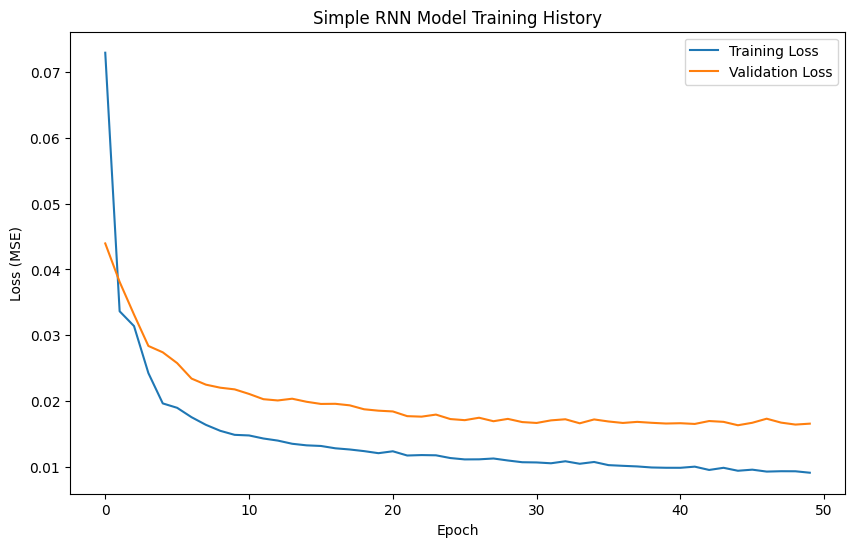

In [10]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use a portion of training data for validation
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


### Evaluate the Simple RNN Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step
Simple RNN Test RMSE: 132.4719


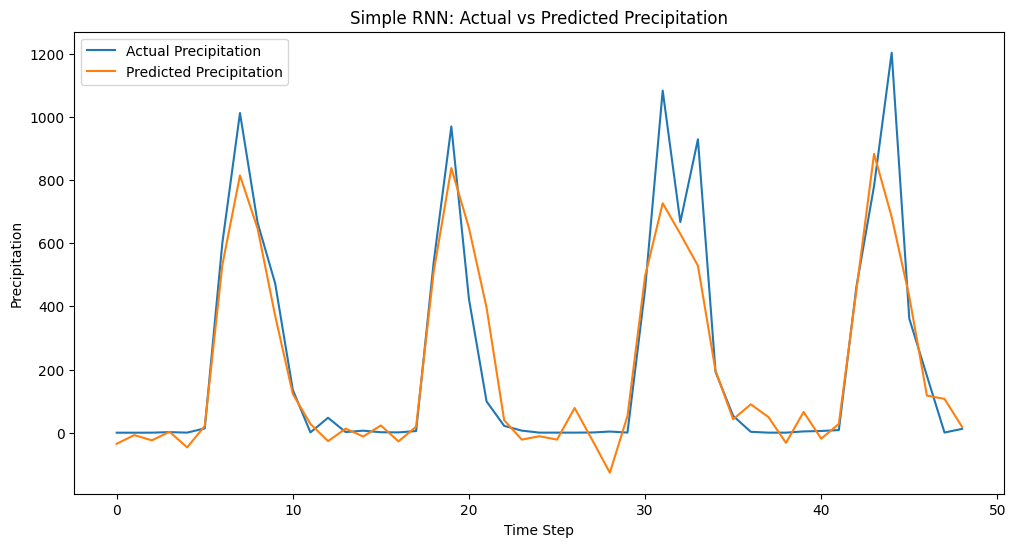

In [11]:
from sklearn.metrics import mean_squared_error

# Make predictions on the test set
y_pred_rnn = model_rnn.predict(X_test)

# Inverse transform the predictions and actual values if data was scaled
# Since we scaled only X and predicted y, we need to consider how y was scaled.
# In create_sequences, y is data[i + seq_length, -1] which is the scaled 'Precipitation'.
# So we need to inverse transform only the 'Precipitation' column from the scaler.
# To do this, we need a dummy array to inverse transform only the last feature.

# Create a dummy array with the same number of features as scaled_data for inverse_transform
dummy_array_for_y_pred = np.zeros((len(y_pred_rnn), scaled_data.shape[1]))
dummy_array_for_y_pred[:, -1] = y_pred_rnn.flatten()

dummy_array_for_y_test = np.zeros((len(y_test), scaled_data.shape[1]))
dummy_array_for_y_test[:, -1] = y_test.flatten()

# Inverse transform
y_pred_rnn_inv = scaler.inverse_transform(dummy_array_for_y_pred)[:, -1]
y_test_inv = scaler.inverse_transform(dummy_array_for_y_test)[:, -1]

# Calculate RMSE
rmse_rnn = np.sqrt(mean_squared_error(y_test_inv, y_pred_rnn_inv))
print(f"Simple RNN Test RMSE: {rmse_rnn:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual Precipitation')
plt.plot(y_pred_rnn_inv, label='Predicted Precipitation')
plt.title('Simple RNN: Actual vs Predicted Precipitation')
plt.xlabel('Time Step')
plt.ylabel('Precipitation')
plt.legend()
plt.show()

The simple RNN model has been trained and evaluated. The RMSE provides a measure of prediction error, and the plots visualize its performance. Next, we can move on to building an RNN with LSTM layers as you requested.

### Build an RNN with LSTM Model

In [13]:
from tensorflow.keras.layers import LSTM

# Define the LSTM model
model_lstm = Sequential([
    LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

The LSTM model is now defined and compiled. Similar to the simple RNN, you can train and evaluate it using `model_lstm.fit` and make predictions.

### Train the LSTM Model

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 472ms/step - loss: 0.0566 - val_loss: 0.0560
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0527 - val_loss: 0.0528
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0494 - val_loss: 0.0496
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0450 - val_loss: 0.0464
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0415 - val_loss: 0.0428
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0358 - val_loss: 0.0374
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0313 - val_loss: 0.0334
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0269 - val_loss: 0.0302
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0236 - val_loss: 0.0301
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0225 - val_loss: 0.0290
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0222 - val_loss: 0.0285
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0220 - val_loss: 0.0278


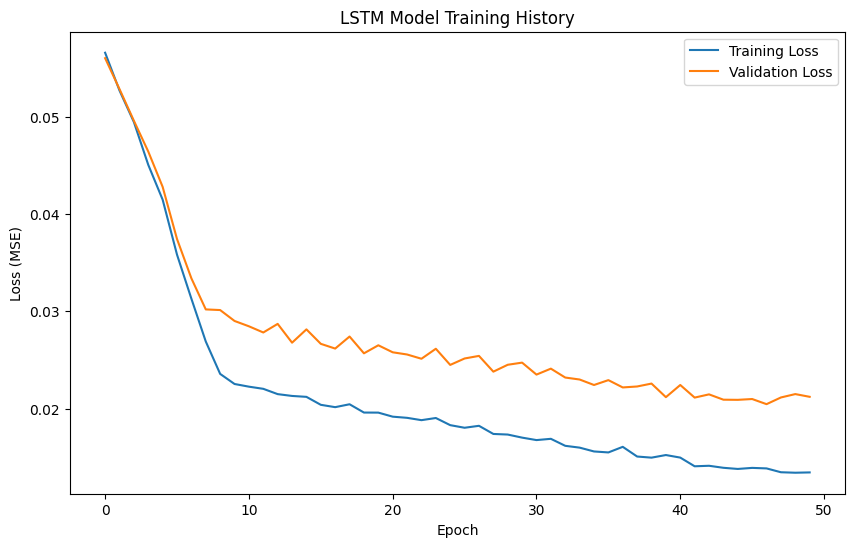

In [15]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use a portion of training data for validation
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

### Evaluate the LSTM Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
LSTM Test RMSE: 145.6057


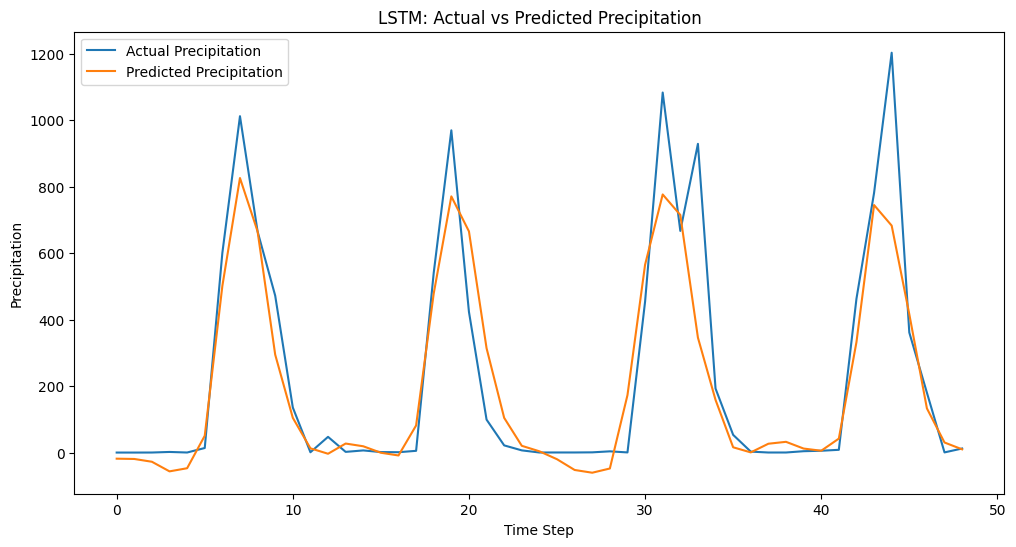

In [16]:
# Make predictions on the test set
y_pred_lstm = model_lstm.predict(X_test)

# Inverse transform the predictions and actual values
dummy_array_for_y_pred_lstm = np.zeros((len(y_pred_lstm), scaled_data.shape[1]))
dummy_array_for_y_pred_lstm[:, -1] = y_pred_lstm.flatten()
y_pred_lstm_inv = scaler.inverse_transform(dummy_array_for_y_pred_lstm)[:, -1]

# Calculate RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm_inv))
print(f"LSTM Test RMSE: {rmse_lstm:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual Precipitation')
plt.plot(y_pred_lstm_inv, label='Predicted Precipitation')
plt.title('LSTM: Actual vs Predicted Precipitation')
plt.xlabel('Time Step')
plt.ylabel('Precipitation')
plt.legend()
plt.show()

The LSTM model has been trained and evaluated. Now, let's train and evaluate the GRU model.

### Build an RNN with GRU Model

In [14]:
from tensorflow.keras.layers import GRU

# Define the GRU model
model_gru = Sequential([
    GRU(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)
])

# Compile the model
model_gru.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         8,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,451 (33.01 KB)

 Trainable params: 8,451 (33.01 KB)

 Non-trainable params: 0 (0.00 B)

The GRU model is now defined and compiled. You can train and evaluate this model using `model_gru.fit` and make predictions, similar to the simple RNN and LSTM models.

### Train the GRU Model

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 451ms/step - loss: 0.0835 - val_loss: 0.0689
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0653 - val_loss: 0.0612
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0585 - val_loss: 0.0580
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0535 - val_loss: 0.0541
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0489 - val_loss: 0.0504
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0451 - val_loss: 0.0474
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0421 - val_loss: 0.0448
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0390 - val_loss: 0.0423
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0357 - val_loss: 0.0399
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0330 - val_loss: 0.0377
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0304 - val_loss: 0.0351
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0273 - val_loss: 0.0324


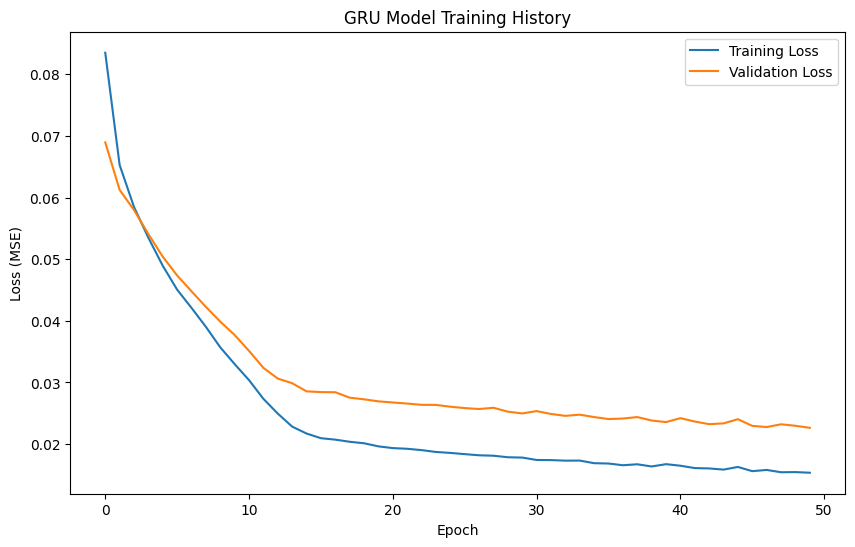

In [17]:
history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use a portion of training data for validation
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

### Evaluate the GRU Model

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
GRU Test RMSE: 158.1394


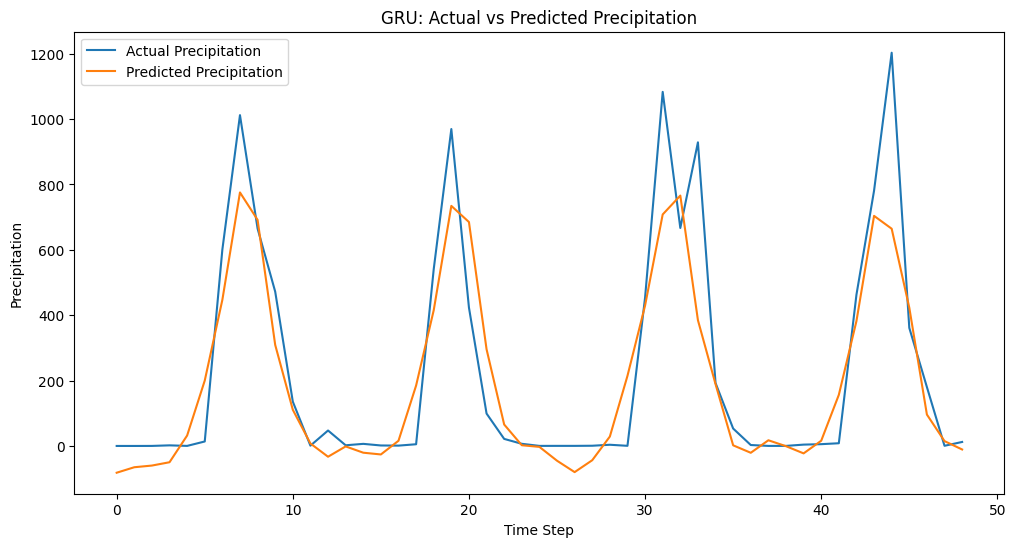

In [18]:
# Make predictions on the test set
y_pred_gru = model_gru.predict(X_test)

# Inverse transform the predictions and actual values
dummy_array_for_y_pred_gru = np.zeros((len(y_pred_gru), scaled_data.shape[1]))
dummy_array_for_y_pred_gru[:, -1] = y_pred_gru.flatten()
y_pred_gru_inv = scaler.inverse_transform(dummy_array_for_y_pred_gru)[:, -1]

# Calculate RMSE
rmse_gru = np.sqrt(mean_squared_error(y_test_inv, y_pred_gru_inv))
print(f"GRU Test RMSE: {rmse_gru:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual Precipitation')
plt.plot(y_pred_gru_inv, label='Predicted Precipitation')
plt.title('GRU: Actual vs Predicted Precipitation')
plt.xlabel('Time Step')
plt.ylabel('Precipitation')
plt.legend()
plt.show()

All three models (Simple RNN, LSTM, and GRU) have now been defined, trained, and evaluated. You can compare their RMSE values and prediction plots to determine which performs best for your specific data.